In [ ]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 47.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import mesolve


In [ ]:
# ==========================================
# 1. PHYSICAL PARAMETERS (The "Space" Specs)
# ==========================================
temperature_kelvin = 403

# A. Photon Loss (Equivalent to Radiative Decay)
lifetime_ns = 1.0
gamma_decay = 1.0 / lifetime_ns

# B. Phase Noise (Radiation-Induced Dephasing)
gamma_dephase_thermal = 0.05 * (temperature_kelvin / 4.0)**2
gamma_dephase_radiation = 0.2
gamma_total_dephase = gamma_dephase_thermal + gamma_dephase_radiation

# C. Background Noise (Stray Light Pumping)
gamma_stray_light = 0.15 * gamma_decay

# Drive intensity (Target mean photon number per pulse)
# For WCP, we define alpha directly.
target_mu = 0.5  # <n> = 0.5 photons per pulse
target_alpha = np.sqrt(target_mu)

In [ ]:
# ==========================================
# 2. DEFINE THE PULSE FUNCTION
# ==========================================
period_ns = 10.0
pulse_width = 0.2
pulse_center = 2.0

# For a coherent drive, the amplitude determines the final alpha displacement
# Amp = target_alpha / (width * sqrt(2*pi))
drive_amp = target_alpha / (pulse_width * np.sqrt(2 * np.pi))

def laser_pulse_shape(t, args):
    envelope = np.exp(-((t - args['center'])**2) / (2 * args['width']**2))
    return envelope

pulse_args = {'center': pulse_center, 'width': pulse_width}


In [ ]:
# ==========================================
# 3. HAMILTONIAN & DYNAMICS (QuTiP Harmonic Oscillator)
# ==========================================
N = 15 # Hilbert space truncation (needs to be > <n>)

a = qt.destroy(N)
n_op = a.dag() * a # Photon number operator
Id = qt.qeye(N)

# Hamiltonian for a coherent drive: H = i * drive(t) * (a.dag() - a)
# This displaces the vacuum into a coherent state
H_drive = 1j * drive_amp * (a.dag() - a)

# Since we assume a resonant laser, the static part is zero
H = [0 * n_op, [H_drive, laser_pulse_shape]]

# Collapse Operators (Noise) - Mapped to Bosonic Mode
c_ops = []
# 1. Photon Loss (Absorption/Scattering in Space)
c_ops.append(np.sqrt(gamma_decay) * a)
# 2. Phase Dephasing (Scrambles the quantum phase of the pulse)
c_ops.append(np.sqrt(gamma_total_dephase) * n_op)
# 3. Background Thermal/Stray Light (Adds noise photons)
c_ops.append(np.sqrt(gamma_stray_light) * a.dag())

In [ ]:
# ==========================================
# 4. MASTER EQUATION SOLVER
# ==========================================
tlist = np.linspace(0, 10, 500)
psi0 = qt.basis(N, 0) # Start in Vacuum State |0>

# Track the mean photon number <n> over time
result = mesolve(H, psi0, tlist, c_ops, [n_op], args=pulse_args)

# For a pulse, the "Average Photon Number" is the peak/steady expectation
max_n = np.max(result.expect[0])

print(f"--- THE VERDICT (WCP Mode) ---")
print(f"Peak Mean Photon Number <n>: {max_n:.4f}")

if max_n > 1.0:
    print("WARNING: High Multi-photon probability! (Security risk for QKD)")
elif max_n < 0.1:
    print("WARNING: Pulse too weak. High loss will make key rate negligible.")
else:
    print("SUCCESS: Weak Coherent Pulse within typical QKD range (0.1 - 0.6).")

--- THE VERDICT (WCP Mode) ---
Peak Mean Photon Number <n>: 0.1764
SUCCESS: Weak Coherent Pulse within typical QKD range (0.1 - 0.6).


In [ ]:
# ==========================================
# 5. QUANTUM METRICS (Fidelity & Purity)
# ==========================================

# 1. Get the final state density matrix (rho)
# We run the solver again without e_ops to get the full state
final_result = mesolve(H, psi0, tlist, c_ops, [], args=pulse_args)
rho_final = final_result.states[-1]

# 2. Define the "Ideal" State
# This is a coherent state with the target alpha, assuming zero noise
ideal_state = qt.coherent(N, target_alpha)

# 3. Calculate Fidelity
# F = <ideal| rho |ideal>
fidelity = qt.fidelity(rho_final, ideal_state)

# 4. Calculate Purity
# P = Tr(rho^2)
purity = (rho_final * rho_final).tr()

print(f"--- QUANTUM CHANNEL ANALYSIS ---")
print(f"State Purity: {purity.real:.4f}")
print(f"Fidelity to Ideal: {fidelity:.4f}")

if fidelity < 0.9:
    print("CRITICAL: High decoherence! QKD secret key rate may drop to zero.")
elif purity.real < 0.95:
    print("WARNING: State is becoming mixed (thermal noise dominant).")
else:
    print("SUCCESS: Quantum info preserved for key generation.")

--- QUANTUM CHANNEL ANALYSIS ---
State Purity: 0.7392
Fidelity to Ideal: 0.7455
CRITICAL: High decoherence! QKD secret key rate may drop to zero.


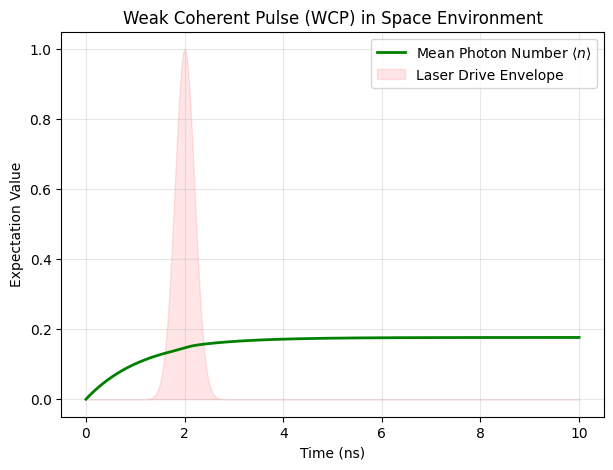

In [ ]:
# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(7, 5))

# Plot 1: The Mean Photon Number (The Pulse Intensity)
plt.plot(tlist, result.expect[0], 'g-', linewidth=2, label=r'Mean Photon Number $\langle n \rangle$')

# Plot 2: The Laser Pulse Trigger
laser_profile = [laser_pulse_shape(t, pulse_args) for t in tlist]
plt.fill_between(tlist, laser_profile, color='red', alpha=0.1, label='Laser Drive Envelope')

plt.title('Weak Coherent Pulse (WCP) in Space Environment', fontsize=12)
plt.xlabel('Time (ns)')
plt.ylabel('Expectation Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

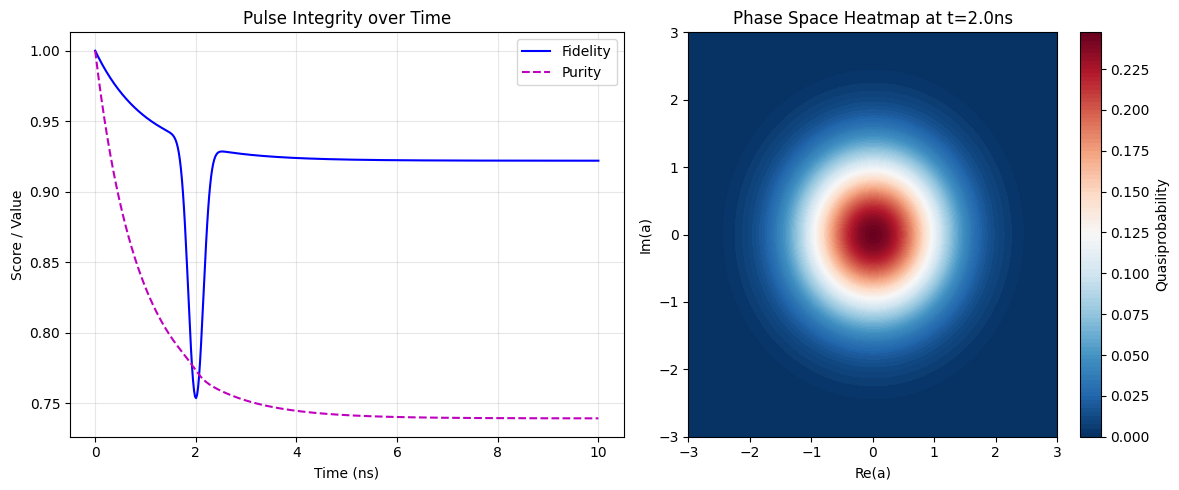

In [ ]:
# ==========================================
# 6. ENHANCED VISUALIZATION (Heatmap & Metrics)
# ==========================================
import matplotlib.gridspec as gridspec

# 1. Calculate metrics over the whole time list
noisy_states = final_result.states
ideal_states = [qt.coherent(N, target_alpha * laser_pulse_shape(t, pulse_args)) for t in tlist]

fidelities = [qt.fidelity(noisy_states[i], ideal_states[i]) for i in range(len(tlist))]
purities = [(s * s).tr().real for s in noisy_states]

# 2. Setup Plotting Grid
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])

# Plot A: Metrics over Time
ax0 = fig.add_subplot(gs[0])
ax0.plot(tlist, fidelities, 'b-', label='Fidelity')
ax0.plot(tlist, purities, 'm--', label='Purity')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Score / Value')
ax0.set_title('Pulse Integrity over Time')
ax0.legend(loc='upper right')
ax0.grid(True, alpha=0.3)

# Plot B: Wigner Heatmap (The "Quantum Snapshot")
# We take the state at the pulse center (where interaction is highest)
center_idx = np.argmin(np.abs(tlist - pulse_center))
rho_at_peak = noisy_states[center_idx]

xvec = np.linspace(-3, 3, 200)
W = qt.wigner(rho_at_peak, xvec, xvec)

ax1 = fig.add_subplot(gs[1])
cont = ax1.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
ax1.set_title(f'Phase Space Heatmap at t={pulse_center}ns')
ax1.set_xlabel('Re(a)')
ax1.set_ylabel('Im(a)')
plt.colorbar(cont, ax=ax1, label='Quasiprobability')

plt.tight_layout()
plt.show()